# Assignment 4 — How Few Components Can You Get Away With?

**Course:** Feature Engineering & MLOps  
**Assignment No.:** 4  
**Topic:** PCA — Explained Variance, Scree Plot, Choosing the Optimal Number of Components

This notebook uses PCA to find the smallest number of components that can achieve approximately the same test performance as the original 60 features.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

pd.set_option("display.float_format", lambda x: f"{x:.6f}")

## 1. Load the Dataset

The assignment uses `pca_regression_data.csv`, containing 800 rows, 60 numeric features (`feature_1` to `feature_60`) and the continuous target `score`.

`student_id` is an identifier, so it is not used as a model feature.

In [2]:
candidate_paths = [
    "/content/pca_regression_data.csv"
]

DATA_PATH = next((path for path in candidate_paths if os.path.exists(path)), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "pca_regression_data.csv was not found. "
        "Place it at data/raw/pca_regression_data.csv or /content/pca_regression_data.csv."
    )

df = pd.read_csv(DATA_PATH)

feature_columns = [f"feature_{i}" for i in range(1, 61)]
target_column = "score"

print("Data path:", DATA_PATH)
print("Shape:", df.shape)
print("\nColumns used for PCA:", len(feature_columns))
display(df.head())

Data path: /content/pca_regression_data.csv
Shape: (800, 62)

Columns used for PCA: 60


,student_id,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,score
0,1,1.006103,2.625090,-0.021036,6.231392,3.147998,-0.044665,-3.420442,1.567874,0.189118,...,3.515794,-1.345712,1.038361,1.358821,4.510162,-0.345406,3.255827,0.607355,1.126482,-0.319225
1,2,4.442871,-2.006560,-1.181818,1.695413,-3.168459,-5.989658,-2.662836,-4.174475,-2.323000,...,1.640106,4.207556,-3.367389,1.398171,1.162581,0.681762,-4.742943,2.150911,-5.587529,3.418536
2,3,1.723720,-3.352754,1.020613,0.533918,3.769766,-0.004683,-0.019345,0.515542,-0.225922,...,0.874327,-0.868329,1.769608,-1.165895,1.189553,3.324718,-1.858829,2.980939,1.121997,2.618471
3,4,0.411140,2.025221,-2.621914,-5.890728,-1.068567,3.413866,3.243600,4.476142,2.650463,...,-0.967199,-1.848642,1.535045,-4.300282,-5.457053,1.066226,2.996332,4.766362,1.312600,-3.740992
4,5,1.011855,3.029584,-2.574027,-1.983156,-1.696483,-2.258118,-1.735768,0.689373,-0.849770,...,-1.185252,-0.883210,0.022223,-1.336599,2.028197,-2.490620,1.414216,-1.392051,0.611356,1.294747


In [3]:
print("Missing values in the 60 features:", df[feature_columns].isna().sum().sum())
print("Target missing values:", df[target_column].isna().sum())

Missing values in the 60 features: 0
Target missing values: 0


# 4.1 — Baseline: All 60 Raw Features

First, we create the baseline using all 60 features. The data is split into training and test sets before standardization so that the scaler learns only from the training data.

In [4]:
X = df[feature_columns]
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train)

baseline_predictions = baseline_model.predict(X_test_scaled)
baseline_r2 = r2_score(y_test, baseline_predictions)

print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")
print(f"Baseline test R²: {baseline_r2:.6f}")

Training rows: 600
Test rows: 200
Baseline test R²: 0.858373


**Baseline result:** Using all 60 standardized features, the Linear Regression model achieves a test R² of **0.858373**.

This value is the reference point for deciding whether a smaller PCA representation is good enough.

# 4.2 — PCA: Explained Variance and the Scree Plot

PCA is fitted only on the standardized training data. The explained variance ratio shows how much of the variation in the training features is captured by each principal component.

In [5]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

variance_table = pd.DataFrame({
    "Component": np.arange(1, len(explained_variance) + 1),
    "Explained Variance Ratio": explained_variance,
    "Cumulative Explained Variance": cumulative_variance
})

display(variance_table.head(10).round(6))

,Component,Explained Variance Ratio,Cumulative Explained Variance
0,1,0.212700,0.212700
1,2,0.180426,0.393125
2,3,0.136387,0.529512
3,4,0.126337,0.655849
4,5,0.115100,0.770949
5,6,0.090079,0.861028
6,7,0.073817,0.934845
7,8,0.053718,0.988563
8,9,0.000605,0.989168
9,10,0.000504,0.989672


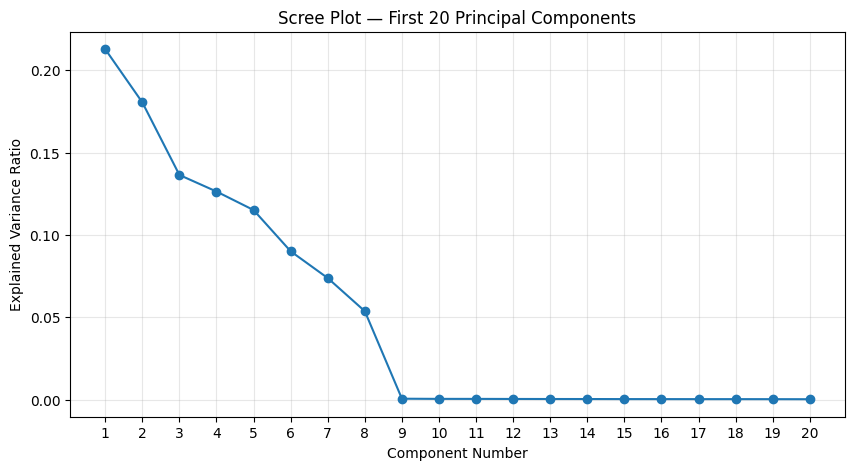

In [6]:
# Scree plot
plt.figure(figsize=(10, 5))
plt.plot(
    np.arange(1, 21),
    explained_variance[:20],
    marker="o"
)
plt.title("Scree Plot — First 20 Principal Components")
plt.xlabel("Component Number")
plt.ylabel("Explained Variance Ratio")
plt.xticks(np.arange(1, 21))
plt.grid(alpha=0.3)
plt.show()

### Visual elbow estimate

From the scree plot alone, the large drops are concentrated in the first few components and the curve becomes much flatter after about **8 components**.

**Visual elbow estimate: approximately 8 components.**

This estimate is recorded before using the model-performance comparison in Section 4.3.

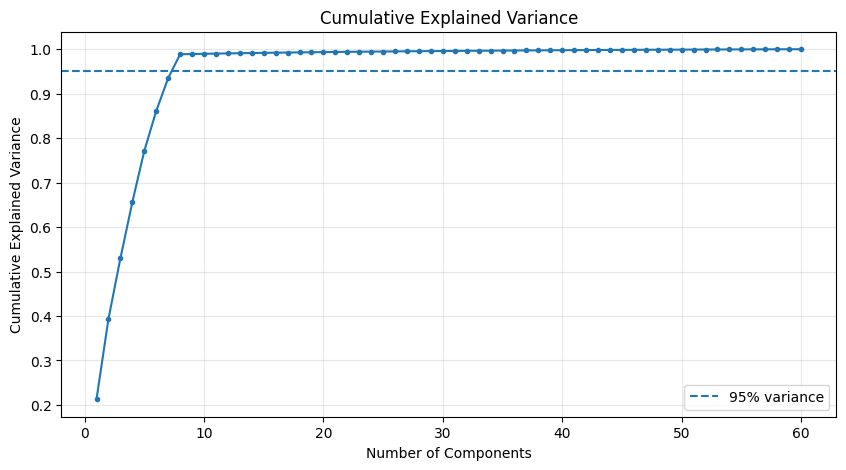

In [7]:
# Cumulative explained variance
plt.figure(figsize=(10, 5))
plt.plot(
    np.arange(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o",
    markersize=3
)
plt.axhline(0.95, linestyle="--", label="95% variance")
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [8]:
components_for_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(
    f"{components_for_95} components are needed to reach "
    f"{cumulative_variance[components_for_95 - 1]:.2%} cumulative explained variance."
)

8 components are needed to reach 98.86% cumulative explained variance.


The cumulative variance plot reaches the 95% reference level at **8 components**. This supports the visual elbow estimate and shows that most of the information in the original 60 features can be represented using a much smaller number of dimensions.

# 4.3 — Find the Smallest Component Count That Matches Baseline Accuracy

Now we test the exact component counts required by the assignment. For every value, PCA is fitted on the training data, both training and test data are transformed, and a fresh Linear Regression model is trained.

In [9]:
component_counts = [2, 4, 6, 8, 10, 12, 15, 20, 30, 40]

results = []

for n_components in component_counts:
    pca = PCA(n_components=n_components)

    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    model = LinearRegression()
    model.fit(X_train_pca, y_train)

    predictions = model.predict(X_test_pca)
    test_r2 = r2_score(y_test, predictions)

    results.append({
        "Components": n_components,
        "Test R²": test_r2,
        "Difference from Baseline": test_r2 - baseline_r2
    })

results_df = pd.DataFrame(results)

display(results_df.round(6))

,Components,Test R²,Difference from Baseline
0,2,0.240924,-0.617449
1,4,0.498896,-0.359477
2,6,0.694589,-0.163784
3,8,0.871584,0.013211
4,10,0.872236,0.013863
5,12,0.871817,0.013444
6,15,0.872381,0.014008
7,20,0.872546,0.014172
8,30,0.866501,0.008128
9,40,0.863369,0.004995


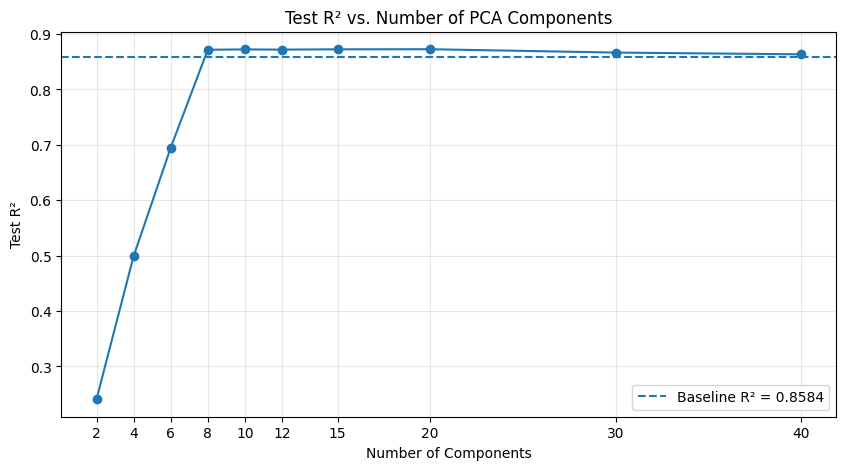

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(
    results_df["Components"],
    results_df["Test R²"],
    marker="o"
)
plt.axhline(
    baseline_r2,
    linestyle="--",
    label=f"Baseline R² = {baseline_r2:.4f}"
)
plt.title("Test R² vs. Number of PCA Components")
plt.xlabel("Number of Components")
plt.ylabel("Test R²")
plt.xticks(component_counts)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [11]:
acceptable_results = results_df[
    results_df["Test R²"] >= baseline_r2 - 0.01
]

smallest_components = int(acceptable_results.iloc[0]["Components"])
smallest_r2 = acceptable_results.iloc[0]["Test R²"]

print(f"Baseline R²: {baseline_r2:.6f}")
print(f"Smallest acceptable component count: {smallest_components}")
print(f"R² with {smallest_components} components: {smallest_r2:.6f}")
print(f"Difference from baseline: {smallest_r2 - baseline_r2:.6f}")

Baseline R²: 0.858373
Smallest acceptable component count: 8
R² with 8 components: 0.871584
Difference from baseline: 0.013211


### Answer: How few components can you get away with?

The **smallest number of components is 8**.

The full 60-feature baseline has a test R² of **0.858373**, while the 8-component PCA model reaches **0.871584**. This is actually higher than the baseline, so it is comfortably within the required 0.01 tolerance.

The visual scree-plot elbow estimate was also **about 8 components**, so the visual and empirical results agree.

# 4.4 — Explain It

The baseline Linear Regression model using all 60 standardized features achieved a test R² of **0.858373**. With only **8 PCA components**, the model achieved a higher test R² of **0.871584**, while the first 8 components capture about **98.86%** of the training-feature variance. This means that most of the useful variation in the original 60 features is concentrated in a much smaller number of underlying dimensions rather than being independently informative. The sharp decline in the scree plot after the first few components also suggests that many of the original features are correlated or redundant. PCA therefore removes much of this redundancy while retaining the important structure, which explains why the smaller representation can match or even improve the Linear Regression performance.

## Final Summary

| Measure | Result |
|---|---:|
| Original features | 60 |
| Baseline test R² | 0.858373 |
| Components needed for 95% variance | 8 |
| Smallest acceptable PCA count | 8 |
| Test R² with 8 components | 0.871584 |
| Visual scree-plot elbow | ~8 |

**Final answer: 8 principal components.**